# Pearson Correlation Heatmaps — US + Global features

Hierarchically-clustered Pearson correlation matrices for the 25-feature
predictor set, separately for the U.S. (with `NOx Mass (lbs)`) and global
(with `annual_nox_emission`) datasets. **Interference-zone filter applied**
(matches paper §3.2 model-training subset: 171 U.S. plants, 1065 global
plants).

**Paths (paper revision)**:
- US: `pipeline_100m_run/Run_100m_20260414/...augmented_localtz.csv` (100 m wind, LST-fixed)
- World: `Run_3/updated_tropomi_emissions_full_variables_with_fuel.csv` (10 m TROPOMI/ERA5 features)
  + `wind_u/v/wind_speed` overridden with 100 m ERA5 from the 2026-04-28 stage-2 re-run
- US interference filter: per-year (2019–2024) plant-vs-plant + city masking
- Global interference filter: plant-vs-plant + city masking on top-6000 by emission

**Output**: `results/paper_figures/{global,us}_pearson_correlation_filtered.pdf`


In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster import hierarchy
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import LabelEncoder

plt.rcdefaults()
plt.style.use('seaborn-v0_8-white')
plt.rcParams['font.family'] = 'Nimbus Roman'
plt.rcParams['font.size']   = 10

# ── Paths (paper revision) ──────────────────────────────────────────────────
# US: 2026-04-28 LST-fixed augment (100 m ERA5 wind + LST hour-of-day for NOx)
US_HOURLY_CSV = '/net/fs06/d3/rzhuang/TROPOMI/pipeline_100m_run/Run_100m_20260414/updated_tropomi_hourly_emissions_full_variables_augmented_localtz.csv'
# World: Run_3 full-variables csv (10 m TROPOMI/ERA5 features) is the base;
# we then OVERRIDE wind_u / wind_v / wind_speed with the 100 m ERA5 wind
# from the 100 m stage-2 re-run (only the wind labelling changed; other
# TROPOMI/ERA5 features are independent of wind-height choice).
WORLD_BASE_CSV         = '/net/fs06/d3/rzhuang/TROPOMI/data/world/Run_3/updated_tropomi_emissions_full_variables_with_fuel.csv'
WORLD_100M_STAGE2_CSV  = '/net/fs06/d3/rzhuang/TROPOMI/data/world/pipeline_test_labelling_100m/Run_100m_20260428/valid_tropomi_emissions_with_qa.csv'

OUTPUT_DIR    = '/net/fs06/d3/rzhuang/TROPOMI/results/paper_figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Style ───────────────────────────────────────────────────────────────────
COLORS = {
    'primary': '#2E86AB', 'secondary': '#A23B72', 'accent': '#F18F01',
    'dark': '#2D3142', 'light': '#F7F7F7', 'bg': '#FFFFFF', 'text': '#333333',
}


In [12]:
# ── Helpers (heatmap + interference filter) ────────────────────────────────
EARTH_RADIUS_KM = 6371.0
PLANT_RADIUS_BASE_KM = 20.0
PLANT_MAX_SEARCH_KM = 150.0
CITY_POP_THRESHOLD = 200000
CITY_RADIUS_SCALE = 9.0
CITY_RADIUS_BASE_KM = 10.0
CITY_RADIUS_MAX_KM = 90.0
US_YEARS = [2019, 2020, 2021, 2022, 2023, 2024]

LABEL_MAPPING = {
    'sensor_azimuth_angle':                  'sensor azimuth angle',
    'sensor_zenith_angle':                   'sensor zenith angle',
    'sensor_altitude':                       'sensor altitude',
    'scaled_small_pixel_variance':           'scaled small-pixel variance',
    'annual_nox_emission':                   'annual NOx emission',
    'wind_speed':                            'wind speed',
    'cloud_albedo_crb':                      'cloud albedo',
    'cloud_pressure_crb':                    'cloud pressure',
    'cloud_fraction_crb':                    'cloud fraction',
    'solar_zenith_angle':                    'solar zenith angle',
    'solar_azimuth_angle':                   'solar azimuth angle',
    'apparent_scene_pressure':               'apparent scene pressure',
    'aerosol_index_354_388':                 'aerosol index 354–388',
    't2m':                                   '2 m temperature',
    'tcwv':                                  'total column water vapour',
    'tisr':                                  'TOA incident solar radiation',
    'surface_classification':                'surface classification',
    'surface_pressure':                      'surface pressure',
    'snow_ice_flag':                         'snow/ice flag',
    'scene_albedo':                          'scene albedo',
    'surface_albedo_nitrogendioxide_window': 'surface albedo NO2 window',
    'surface_albedo':                        'surface albedo',
    'surface_altitude':                      'surface altitude',
    'surface_altitude_precision':            'surface altitude precision',
    'primary_fuel_type':                     'primary fuel type',
    'NOx Mass (lbs)':                        'hourly NOx emissions',
}

def _cluster_corr(corr):
    from scipy.cluster import hierarchy
    pairwise = 1 - np.abs(corr)
    linkage  = hierarchy.linkage(pairwise, method='average')
    return hierarchy.dendrogram(linkage, no_plot=True)['leaves']

def create_pearson_correlation_heatmap(df, features, title, save_path):
    """Pearson correlation heatmap with hierarchical-clustering ordering."""
    pearson = df[features].corr(method='pearson')

    fig = plt.figure(figsize=(15, 9))
    fig.patch.set_facecolor(COLORS['bg'])

    # Diverging blue → white → red (canonical RdBu_r ordering, light-pink
    # near +0.1 and dark-red at +1; fixed 2026-04-29 from earlier reversed bug)
    colors_neg = ['#053061', '#2166ac', '#4393c3', '#92c5de', '#d1e5f0']
    colors_pos = ['#fddbc7', '#f4a582', '#d6604d', '#b2182b', '#67001f']
    cmap = LinearSegmentedColormap.from_list(
        'custom', colors_neg + ['#f7f7f7'] + colors_pos, N=100)

    order = _cluster_corr(pearson)
    pearson_ord = pearson.iloc[order, order]
    short_labels = [LABEL_MAPPING.get(c, c) for c in pearson_ord.columns]

    ax = fig.add_subplot(111)
    mask = np.triu(np.ones_like(pearson_ord), k=1)
    sns.heatmap(pearson_ord, mask=mask, cmap=cmap, center=0,
                square=False, linewidths=0.5, linecolor='white',
                cbar_kws={'shrink': 0.8, 'pad': 0.02,
                          'label': 'Pearson Correlation Coefficient'},
                vmin=-1, vmax=1, ax=ax, annot=False,
                xticklabels=short_labels, yticklabels=short_labels)

    ax.set_title(title, fontsize=24, fontweight='bold',
                 pad=25, color=COLORS['dark'], fontfamily='Nimbus Roman')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right',
                       fontsize=10, color=COLORS['text'])
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0,
                       fontsize=10, color=COLORS['text'])
    ax.tick_params(axis='both', which='major', labelsize=10,
                   colors=COLORS['text'], length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    rect = Rectangle((0, 0), len(short_labels), len(short_labels),
                     fill=False, edgecolor=COLORS['dark'], linewidth=2)
    ax.add_patch(rect)

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=11, colors=COLORS['text'])
    cbar.ax.yaxis.label.set_color(COLORS['text'])
    cbar.ax.yaxis.label.set_fontsize(12)
    cbar.outline.set_edgecolor(COLORS['dark'])
    cbar.outline.set_linewidth(2)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight',
                facecolor=COLORS['bg'], edgecolor='none')
    plt.show()
    return pearson_ord

def identify_highly_correlated_features(corr_matrix, threshold=0.8):
    """Top |correlation| > threshold pairs (printed + returned)."""
    pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            v = abs(corr_matrix.iloc[i, j])
            if v > threshold:
                pairs.append({'feature1': corr_matrix.columns[i],
                              'feature2': corr_matrix.columns[j],
                              'correlation': corr_matrix.iloc[i, j]})
    pairs.sort(key=lambda x: abs(x['correlation']), reverse=True)
    print(f'\nFound {len(pairs)} feature pairs with |correlation| > {threshold}')
    for p in pairs[:30]:
        print(f"{p['feature1']} <-> {p['feature2']}: {p['correlation']:.3f}")
    return pairs


# ─── Interference-filter helpers ───────────────────────────────────────────
from sklearn.neighbors import BallTree
from haversine import haversine, Unit
from math import radians, log10

def _proc_source_df(df, lat_col, lon_col, id_col, val_col):
    """Return (clean df, BallTree) for nearby-source lookup."""
    if df is None or df.empty:
        return None, None
    d = df[[lat_col, lon_col, id_col, val_col]].rename(
        columns={lat_col: 'lat', lon_col: 'lon', id_col: 'ID', val_col: 'val'}
    ).copy()
    for c in ['lat', 'lon', 'val']:
        d[c] = pd.to_numeric(d[c], errors='coerce')
    d.dropna(subset=['lat', 'lon'], inplace=True)
    if d.empty:
        return d, None
    d['lat_r'] = np.radians(d.lat)
    d['lon_r'] = np.radians(d.lon)
    return d, BallTree(d[['lat_r', 'lon_r']].values, metric='haversine')

def identify_us_interference_one_year(plants_year_df, cities_df):
    """Return (plant-interfered IDs, city-interfered IDs) for a single US year."""
    sp, pt = _proc_source_df(plants_year_df, 'Latitude', 'Longitude',
                             'Facility ID', 'NOx Mass (short tons)')
    sc, ct = _proc_source_df(cities_df, 'latitude', 'longitude', 'name', 'population')
    plant_int, city_int = set(), set()
    if plants_year_df.empty:
        return plant_int, city_int
    for _, t in plants_year_df.iterrows():
        tid = t['Facility ID']; tla = t['Latitude']; tlo = t['Longitude']
        te = t.get('NOx Mass (short tons)', 0)
        if pd.isna(tla) or pd.isna(tlo) or pd.isna(te): continue
        rad = np.array([[radians(tla), radians(tlo)]])
        if pt is not None:
            for j in pt.query_radius(rad, r=PLANT_MAX_SEARCH_KM/EARTH_RADIUS_KM)[0]:
                s = sp.iloc[j]
                if s.ID == tid or pd.isna(s.val) or s.val < te: continue
                if haversine((tla,tlo),(s.lat,s.lon),unit=Unit.KILOMETERS) < PLANT_RADIUS_BASE_KM:
                    plant_int.add(tid); break
        if ct is not None:
            for j in ct.query_radius(rad, r=CITY_RADIUS_MAX_KM/EARTH_RADIUS_KM)[0]:
                c = sc.iloc[j]
                if pd.isna(c.val) or c.val < CITY_POP_THRESHOLD: continue
                rr = min(CITY_RADIUS_BASE_KM + log10(max(1,c.val))*CITY_RADIUS_SCALE,
                         CITY_RADIUS_MAX_KM)
                if haversine((tla,tlo),(c.lat,c.lon),unit=Unit.KILOMETERS) < rr:
                    city_int.add(tid); break
    return plant_int, city_int

def identify_global_interference(plants_df, cities_df):
    """Return set of interfered plant IDs in the global top-6000 cohort."""
    dp = plants_df.copy()
    dp['ann'] = dp.get('nox_emis_ty', -dp.index)
    dp['lat_r'] = np.radians(dp.latitude); dp['lon_r'] = np.radians(dp.longitude)
    pt = BallTree(dp[['lat_r','lon_r']].values, metric='haversine')
    cf = cities_df[cities_df.population >= CITY_POP_THRESHOLD].copy()
    cf['lat_r'] = np.radians(cf.latitude); cf['lon_r'] = np.radians(cf.longitude)
    ct = BallTree(cf[['lat_r','lon_r']].values, metric='haversine')

    out = set()
    ids = dp.ID.values; lats = dp.latitude.values; lons = dp.longitude.values
    emis = dp.ann.values
    for i in range(len(dp)):
        tla,tlo,te = lats[i], lons[i], emis[i]
        if pd.isna(tla) or pd.isna(tlo): continue
        rad = np.array([[radians(tla), radians(tlo)]])
        flag = False
        for j in pt.query_radius(rad, r=PLANT_MAX_SEARCH_KM/EARTH_RADIUS_KM)[0]:
            if j == i: continue
            if pd.notna(emis[j]) and emis[j] > te:
                if haversine((tla,tlo),(lats[j],lons[j]),unit=Unit.KILOMETERS) < PLANT_RADIUS_BASE_KM:
                    out.add(str(ids[i])); flag = True; break
        if flag: continue
        for j in ct.query_radius(rad, r=CITY_RADIUS_MAX_KM/EARTH_RADIUS_KM)[0]:
            c = cf.iloc[j]
            rr = min(CITY_RADIUS_BASE_KM + log10(max(1,c.population))*CITY_RADIUS_SCALE,
                     CITY_RADIUS_MAX_KM)
            if haversine((tla,tlo),(c.latitude,c.longitude),unit=Unit.KILOMETERS) < rr:
                out.add(str(ids[i])); break
    return out


In [13]:
# ── Feature lists ───────────────────────────────────────────────────────────
FEATURES_WORLD = [
    'annual_nox_emission', 'surface_altitude', 'surface_altitude_precision',
    'surface_classification', 'surface_pressure', 'surface_albedo',
    'surface_albedo_nitrogendioxide_window', 'cloud_pressure_crb',
    'cloud_fraction_crb', 'cloud_albedo_crb', 'scene_albedo',
    'apparent_scene_pressure', 'snow_ice_flag', 'aerosol_index_354_388',
    'scaled_small_pixel_variance',
    'sensor_altitude', 'sensor_azimuth_angle', 'sensor_zenith_angle',
    'solar_azimuth_angle', 'solar_zenith_angle', 'wind_speed',
    't2m', 'tisr', 'tcwv',
    'primary_fuel_type',
]

FEATURES_US = [
    'surface_altitude', 'surface_altitude_precision',
    'surface_classification', 'surface_pressure', 'surface_albedo',
    'surface_albedo_nitrogendioxide_window', 'cloud_pressure_crb',
    'cloud_fraction_crb', 'cloud_albedo_crb', 'scene_albedo',
    'apparent_scene_pressure', 'snow_ice_flag', 'aerosol_index_354_388',
    'scaled_small_pixel_variance',
    'sensor_altitude', 'sensor_azimuth_angle', 'sensor_zenith_angle',
    'solar_azimuth_angle', 'solar_zenith_angle', 'wind_speed',
    't2m', 'tisr', 'tcwv',
    'primary_fuel_type', 'NOx Mass (lbs)',
]


Processing global data ...
  Run_3 base:          875,580 rows | 60 cols
  100 m stage-2:       875,686 rows
  matched 100 m wind:   875,580 / 875,580 (100.00%)
  After dropna():      875,580 rows (dropped 0)
  Applying interference filter ...
  Global interfered: 4935, kept: 1065 plants
  After filter:        161,118 rows from 1065 plants
Global fuel-type mapping: {'biomass': 0, 'coal': 1, 'natural gas': 2, 'oil': 3, 'waste': 4}


/tmp/ipykernel_1598209/3294604215.py:43: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage  = hierarchy.linkage(pairwise, method='average')


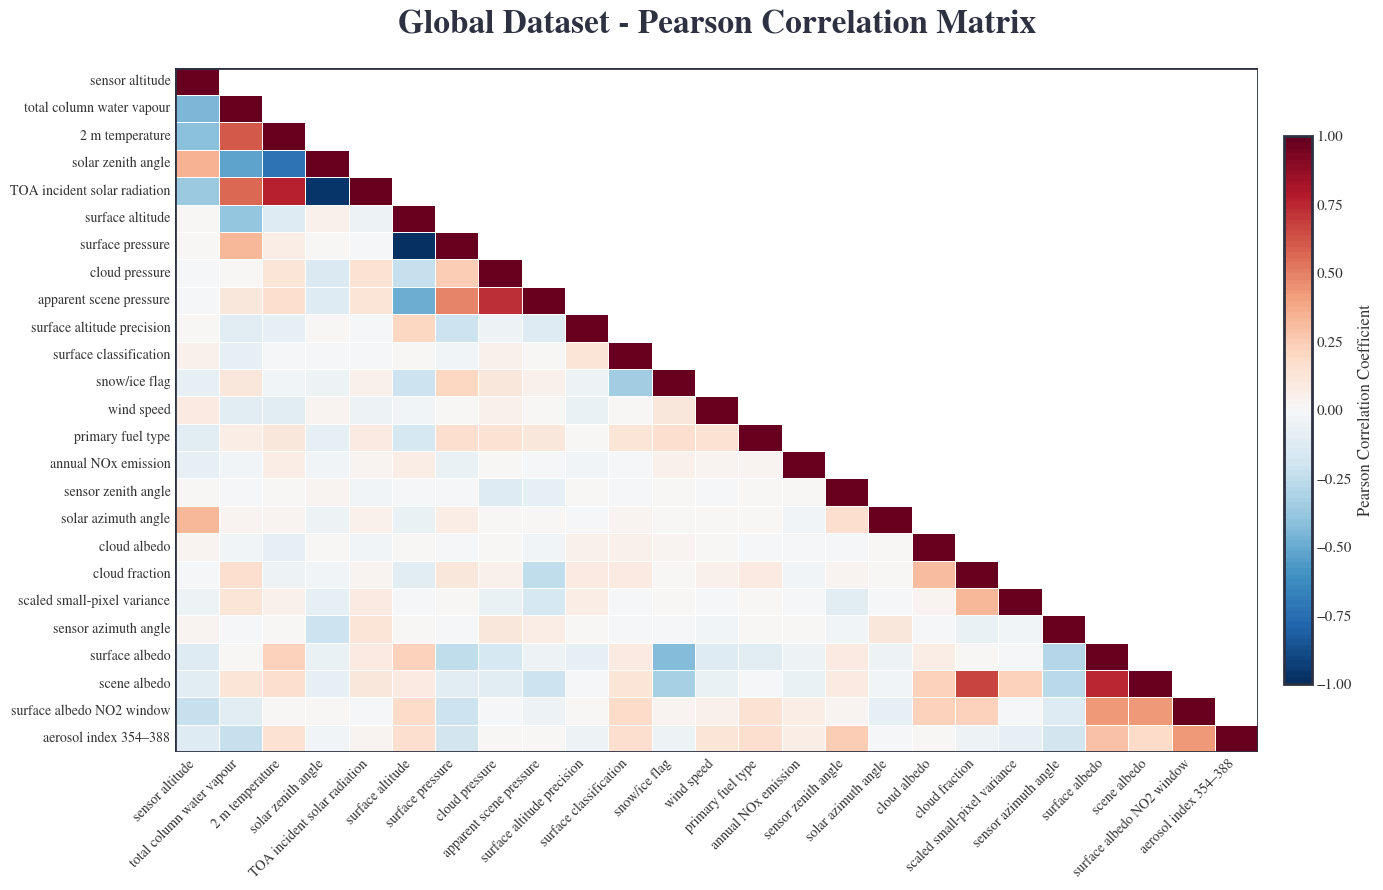


Highly correlated features in global data:

Found 2 feature pairs with |correlation| > 0.8
surface_altitude <-> surface_pressure: -0.986
solar_zenith_angle <-> tisr: -0.963


In [14]:
# ── Global correlation heatmap (interference-filtered, 100 m wind merged) ──
print('Processing global data ...')
tropomi_world = pd.read_csv(WORLD_BASE_CSV)
print(f'  Run_3 base:        {len(tropomi_world):>9,} rows | {len(tropomi_world.columns)} cols')

# 1) Override wind with 100 m ERA5 from the 2026-04-28 stage-2 re-run
wind_100m = pd.read_csv(WORLD_100M_STAGE2_CSV,
                        usecols=['location', 'utc_time', 'wind_u', 'wind_v'])
print(f'  100 m stage-2:     {len(wind_100m):>9,} rows')
merged = tropomi_world.merge(
    wind_100m.rename(columns={'wind_u': 'wind_u_100m', 'wind_v': 'wind_v_100m'}),
    on=['location', 'utc_time'], how='left')
n_match = int(merged['wind_u_100m'].notna().sum())
match_pct = 100.0 * n_match / len(merged)
print(f'  matched 100 m wind: {n_match:>9,} / {len(merged):,} ({match_pct:.2f}%)')
assert match_pct >= 99.0, f'100 m wind match rate {match_pct:.2f}% unexpectedly low'
mask = merged['wind_u_100m'].notna()
merged.loc[mask, 'wind_u'] = merged.loc[mask, 'wind_u_100m']
merged.loc[mask, 'wind_v'] = merged.loc[mask, 'wind_v_100m']
merged['wind_speed'] = np.hypot(merged['wind_u'], merged['wind_v'])
merged = merged.drop(columns=['wind_u_100m', 'wind_v_100m'])
tropomi_world = merged

# Drop rows with NaN in any column (matches the .dropna() on US side; ensures
# the Pearson correlation uses a single common-rows subset across all features)
n_before = len(tropomi_world)
tropomi_world = tropomi_world.dropna()
print(f'  After dropna():    {len(tropomi_world):>9,} rows '
      f'(dropped {n_before - len(tropomi_world):,})')

# 2) Apply interference filter (top-6000 by emission, drop plant-or-city interfered)
print('  Applying interference filter ...')
cities_df = pd.read_csv('/net/fs06/d3/rzhuang/TROPOMI/data/world/worldcities.csv')
g_loc = pd.read_csv('/net/fs06/d3/rzhuang/TROPOMI/data/world/power_plant_location/power_plants_with_combined_nearby_stats.csv')
g_sub = g_loc.sort_values('nox_emis_ty', ascending=False).head(6000).copy()
g_int = identify_global_interference(g_sub, cities_df)
keep_g = set(map(str, g_sub.ID)) - g_int
print(f'  Global interfered: {len(g_int):>4d}, kept: {len(keep_g):>4d} plants')
tropomi_world = tropomi_world[tropomi_world['location'].astype(str).isin(keep_g)].copy()
print(f'  After filter:      {len(tropomi_world):>9,} rows from {tropomi_world["location"].nunique()} plants')

# 3) Encode primary_fuel_type
le_world = LabelEncoder()
tropomi_world['primary_fuel_type'] = le_world.fit_transform(tropomi_world['primary_fuel_type'])
print(f'Global fuel-type mapping: {dict(zip(le_world.classes_, le_world.transform(le_world.classes_)))}')

pearson_world = create_pearson_correlation_heatmap(
    tropomi_world, FEATURES_WORLD,
    'Global Dataset - Pearson Correlation Matrix',
    os.path.join(OUTPUT_DIR, 'global_pearson_correlation_filtered.pdf'),
)
print('\nHighly correlated features in global data:')
high_corr_world = identify_highly_correlated_features(pearson_world)




Processing US data ...
  US base (post-dropna):   501,720 rows from 500 plants
  Applying per-year interference filter ...
  US complete-6y plants: 460; interfered (any year): 289
  US kept: 171 plants
  After filter:             189,713 rows from 171 plants
US fuel-type mapping: {'Coal': 0, 'Coal Refuse': 1, 'Coal, Natural Gas': 2, 'Natural Gas': 3, 'Natural Gas, Pipeline Natural Gas': 4, 'Other Gas': 5, 'Petroleum Coke': 6, 'Pipeline Natural Gas': 7, 'Residual Oil': 8, 'Wood': 9}


/tmp/ipykernel_1598209/3294604215.py:43: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage  = hierarchy.linkage(pairwise, method='average')


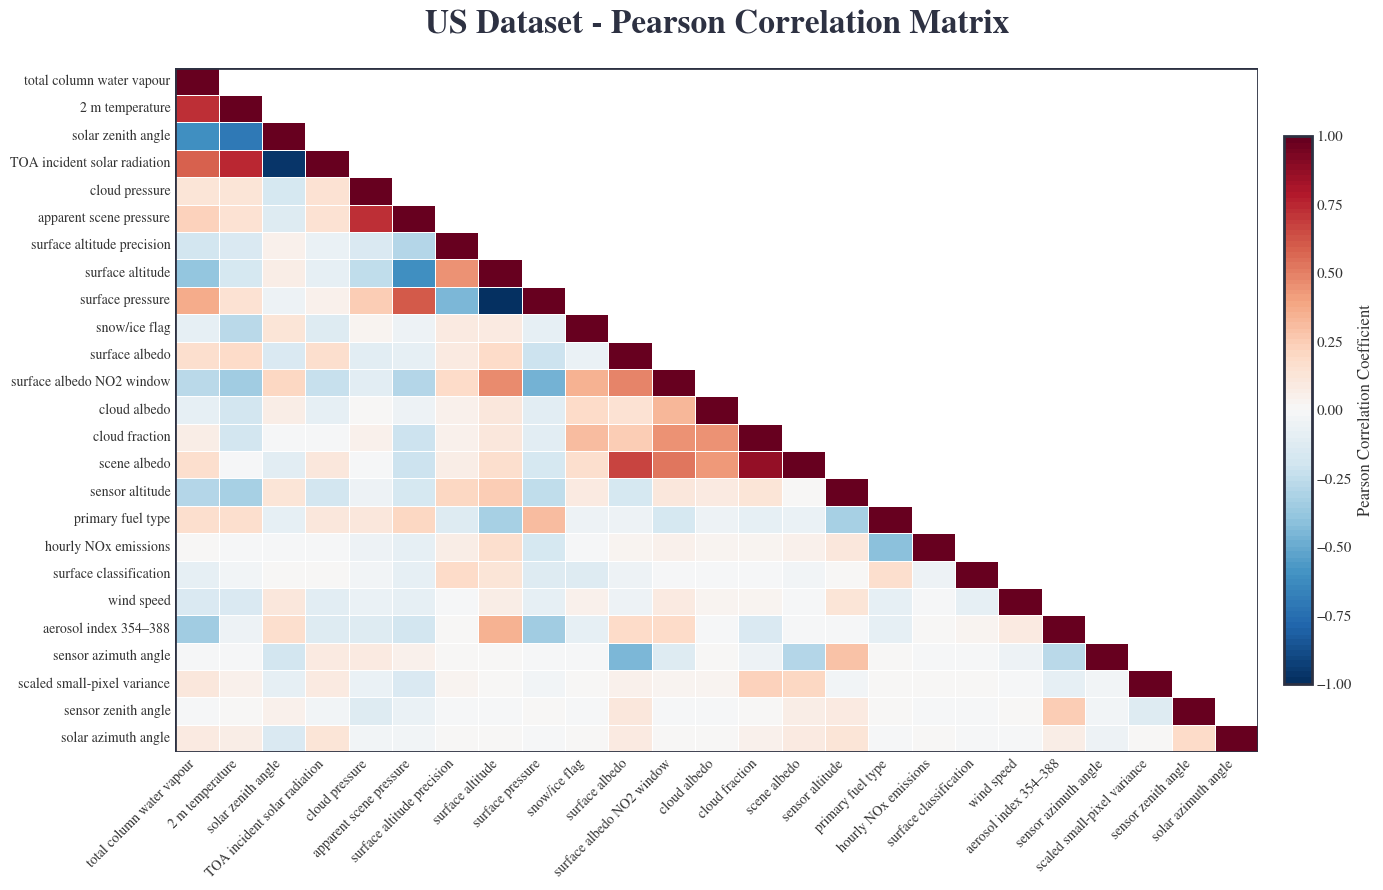


Highly correlated features in US data:

Found 3 feature pairs with |correlation| > 0.8
surface_altitude <-> surface_pressure: -0.994
solar_zenith_angle <-> tisr: -0.974
cloud_fraction_crb <-> scene_albedo: 0.863


In [15]:
# ── US correlation heatmap (interference-filtered, LST-fixed augment) ──────
print('\n\nProcessing US data ...')
tropomi_us = pd.read_csv(US_HOURLY_CSV).dropna()
print(f'  US base (post-dropna): {len(tropomi_us):>9,} rows from {tropomi_us["location"].nunique()} plants')
tropomi_us['year'] = pd.to_datetime(tropomi_us['utc_time'], utc=True, format='ISO8601').dt.year

# Apply per-year interference filter (matches §3.2 model-training subset)
print('  Applying per-year interference filter ...')
us_loc = pd.read_csv('/net/fs06/d3/rzhuang/TROPOMI/data/us/facility_emissions_by_plant_comprehensive.csv')
if 'NOx_Rank' in us_loc.columns:
    us_loc = us_loc.sort_values('NOx_Rank', ascending=True)
top500_ids = set(us_loc.head(500)['Facility_ID'])
us_annual = pd.read_csv('/net/fs06/d3/rzhuang/TROPOMI/data/us/annual-emissions-facility-aggregation-2019-2024.csv')
us_a = us_annual[us_annual['Facility ID'].isin(top500_ids)].copy()
present = us_a[us_a['Year'].isin(US_YEARS)].groupby('Facility ID')['Year'].nunique()
complete_6y = set(present[present == len(US_YEARS)].index)
us_a = us_a.dropna(subset=['Latitude', 'Longitude'])

cities_us = cities_df  # reuse from global block

union_us_int = set()
for yr in US_YEARS:
    df_y = us_a[(us_a['Year'] == yr) & (us_a['Facility ID'].isin(complete_6y))].copy()
    if df_y.empty: continue
    p_int, c_int = identify_us_interference_one_year(df_y, cities_us)
    union_us_int |= set(map(str, p_int.union(c_int)))
complete_str = set(map(str, complete_6y))
kept_us_ids = complete_str - union_us_int
print(f'  US complete-6y plants: {len(complete_6y)}; interfered (any year): {len(union_us_int)}')
print(f'  US kept: {len(kept_us_ids)} plants')
tropomi_us = tropomi_us[tropomi_us['location'].astype(str).isin(kept_us_ids)].copy()
print(f'  After filter:           {len(tropomi_us):>9,} rows from {tropomi_us["location"].nunique()} plants')

# Encode primary_fuel_type
le_us = LabelEncoder()
tropomi_us['primary_fuel_type'] = le_us.fit_transform(tropomi_us['primary_fuel_type'])
print(f'US fuel-type mapping: {dict(zip(le_us.classes_, le_us.transform(le_us.classes_)))}')

pearson_us = create_pearson_correlation_heatmap(
    tropomi_us, FEATURES_US,
    'US Dataset - Pearson Correlation Matrix',
    os.path.join(OUTPUT_DIR, 'us_pearson_correlation_filtered.pdf'),
)
print('\nHighly correlated features in US data:')
high_corr_us = identify_highly_correlated_features(pearson_us)
